## Find Colocated PACE and EMIT Data
Adapted from the LP.DAAC VITALS ["Finding Concurrent ECOSTRESS and EMIT Data"](https://nasa.github.io/VITALS/python/01_Finding_Concurrent_Data.html) tutorial.

Original Author: Erik Bolch (USGS)

Adapted for PACE by: Skye Caplan (NASA, SSAI)

Last updated: 03/31/2026

[edl]: https://urs.earthdata.nasa.gov/

<div class="alert alert-info" role="alert">

An [Earthdata Login][edl] account is required to access data from the NASA Earthdata system, including NASA PACE and EMIT data.

</div>

## Summary

The Plankton, Aerosol, Cloud, ocean Ecosystem (PACE) mission and the Earth Surface Mineral Dust Source Investigation (EMIT) sensor aboard the International Space Station (ISS) both make hyperspectral observations of the Earth's surface. Taking into account their different spectral, spatial, and temporal coverage, these instruments' capabilities are extremely complementary and provide a wealth of new opportunities when used in concert. In this series of tutorials, we will demonstrate how to find, prepare, and use data from both PACE and EMIT together, illustarting each missions' strengths and where they can fill in each others' gaps. 

In this first tutorial in the series, we will pull data from the EMIT and PACE, specifically PACE's Ocean Color Instrument (OCI), using the `earthaccess` Python library, and demonstrate how to find colocated granules using file metadata. Ultimately, these data will be used in a case study analyzing 2024-25 wildfires affecting Grampians National Park in Victoria, Australia. The next tutorial in the series, `02_Align_PACE_EMIT_Grids`, will demonstrate how to grid both PACE and EMIT data.

## Learning Objectives

At the end of this notebook, you will know how to:
- Search for both PACE and EMIT data using the `earthaccess` package
- Filter those search results to find concurrent datasets based on overpass time, cloud cover, etc.
- Download only the datasets which match your filter criteria. 

## Contents
1. [Setup](#1.-Setup)
2. [Searching for Data](#2.-Searching-for-Data)
3. [Filtering Data](#3.-Filtering-Data)
4. [Downloading Data](#4.-Downloading-Data)


## 1. Setup

Begin by importing all of the packages used in this notebook.

In [ ]:
import folium
import earthaccess
import numpy as np 
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from skimage import io
from shapely import geometry
from datetime import timedelta
from branca.element import Figure
from IPython.display import display
from shapely.geometry import Polygon, box

## 2. Searching for Data
The following cells will allow you to log in to Earthdata just as you would through a browser. We will then define parameters to begin our search for data, using a specific timespan, a region of interest (ROI), and the products we are looking for, in this case surface reflectance.

To begin, we will use the `earthaccess.login()` method to access your Earthdata account and allow you to download NASA data. Note that you can add `persist=True` as an argument to `earthaccess.login()` to save your credentials in a `.netrc` file, so you won't need to login using your Earthdata credentials each time you use this notebook.

In [2]:
auth = earthaccess.login()

Next, we will define time period and spatial boundaries of the area we are interested in. Given that last tutorial in this series will look at the Grampians National Park fire in Victoria, Australia, we will grab overlapping reflectance data from both PACE OCI and EMIT. In order to investigate these events, data from both before and after the fires will be necessary, so the steps below will be repeated for both time intervals.

Let's find some granules from both missions which capture the affected areas. The fires occurred from December-February of 2024-2025, within both missions' time frames. However, these two instruments are on very different orbits and with complementary collection characteristics - EMIT data will provide very fine spatial resolution but have sparse coverage, while PACE OCI data will be available daily, but at coarser resolutions. EMIT will then be our limiting factor temporally. Thankfully, we don't need extremely fine temporal resolution for the first part of our analysis using the Normalized Burn Ratio, so we can look for data from ~1-2 months before and after these fires if necessary.

We'll find our pre-fire granules first. Knowing the ROI and that the first fires began on December 17th, 2024, we can set the desired search parameters. We will also need to know the names of the products we want to search for - in this case, we want surface reflectances from both PACE and EMIT, whose product `short_names` are listed in the cell below.

In [ ]:
tspan = ('2024-11-01','2024-12-16')
roi_bounds = (141.9385, -37.74163, 142.77324, -36.79961)

bbox = geometry.box(*roi_bounds, ccw=True)
roi = list(bbox.exterior.coords)
gdf = gpd.GeoDataFrame(index=[0], crs='epsg:4326', geometry=[bbox])

prods = ["PACE_OCI_L2_SFREFL", "EMITL2ARFL"]

With the parameter set, we can use `earthaccess.search_data()` to look through our chosen collections.

In [4]:
results = earthaccess.search_data(
    short_name=prods,
    polygon=roi,
    temporal=tspan,
)

len(results)

71

We can run our search and see that we gathered ~70 granules that match our search parameters. That is a lot of data! Let's examine what the first two results from the `earthaccess` call look like. Running the cell below, we have 2 EMIT granules with all their associated metadata that matched the criteria in our query above. If you were to look through the whole `results` list, you'd see the same for however many PACE OCI granules fit the search parameters as well. We can use these metadata to sort through all of these results to choose the best granules for our analyses.

In [5]:
results[:2]

[Collection: {'ShortName': 'EMITL2ARFL', 'Version': '001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': 141.6588134765625, 'Latitude': -37.22526168823242}, {'Longitude': 140.77365112304688, 'Latitude': -37.822025299072266}, {'Longitude': 141.2333984375, 'Latitude': -38.50394058227539}, {'Longitude': 142.11856079101562, 'Latitude': -37.90717697143555}, {'Longitude': 141.6588134765625, 'Latitude': -37.22526168823242}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-11-14T03:57:35Z', 'EndingDateTime': '2024-11-14T03:57:47Z'}}
 Size(MB): 3577.064754486084
 Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035735_2431902_007/EMIT_L2A_RFL_001_20241114T035735_2431902_007.nc', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035735_2431902_007/EMIT_L2A_RFLUNCERT_001_20241114T035735_243190

## 3. Filtering Data

In order to use the metadata efficiently, and to make it more human-readable, we can put make our list of results into a `GeoDataFrame` by taking the spatial metadata and creating a shapely polygon representing the spatial coverage, and further customize which information we want to use from other metadata fields. These methods are explained more thoroughly in the VITALS ECOSTRESS-EMIT tutorial [`01_Finding_Concurrent_Data`](https://nasa.github.io/VITALS/python/01_Finding_Concurrent_Data.html). 

In [6]:
# Functions to Build Dataframe
def get_shapely_object(result: earthaccess.results.DataGranule):
    """
    Create a shapely polygon of spatial coverage from results metadata.
    Will work for BoundingRectangles or GPolygons.
    """
    # Get Geometry Keys
    geo = result["umm"]["SpatialExtent"]["HorizontalSpatialDomain"]["Geometry"]
    keys = geo.keys()

    if "BoundingRectangles" in keys:
        bounding_rectangle = geo["BoundingRectangles"][0]
        # Create bbox tuple
        bbox_coords = (
            bounding_rectangle["WestBoundingCoordinate"],
            bounding_rectangle["SouthBoundingCoordinate"],
            bounding_rectangle["EastBoundingCoordinate"],
            bounding_rectangle["NorthBoundingCoordinate"],
        )
        # Create shapely geometry from bbox
        shape = box(*bbox_coords, ccw=True)
    elif "GPolygons" in keys:
        points = geo["GPolygons"][0]["Boundary"]["Points"]
        # Create shapely geometry from polygons
        shape = Polygon([[p["Longitude"], p["Latitude"]] for p in points])
    else:
        raise ValueError(
            "Provided result does not contain bounding boxes/polygons or is incompatible."
        )
    return shape

def get_png(result: earthaccess.results.DataGranule):
    """
    Retrieve a png browse image if it exists or first jpg in list of urls
    """
    https_links = [link for link in result.dataviz_links() if "https" in link]
    if len(https_links) == 1:
        browse = https_links[0]
    elif len(https_links) == 0:
        browse = "no browse image"
    else:
        browse = [png for png in https_links if ".png" in png][0]
    if any(browse) == 'no browse image':
        print("Some granules have no browse imagery.")
    return browse

def results_to_gdf(results: list):
    """
    Takes a list of results from earthaccess and converts to a geodataframe.
    """
    # Create Dataframe of Results Metadata
    results_df = pd.json_normalize(results)
    # Shorten column Names
    results_df.columns = [
        col.split(".")[-1] if "." in col else col for col in results_df.columns
    ]
    # Create shapely polygons for result
    geometries = [
        get_shapely_object(results[index]) for index in results_df.index.to_list()
    ]
    # Convert to GeoDataframe
    gdf = gpd.GeoDataFrame(results_df, geometry=geometries, crs="EPSG:4326")
    # Add browse imagery and data links and product shortname
    gdf["browse"] = [get_png(granule) for granule in results]
    gdf["shortname"] = [
        result["umm"]["CollectionReference"]["ShortName"] for result in results
    ]
    gdf["data"] = [granule.data_links() for granule in results]
    return gdf

gdf = results_to_gdf(results)

In [7]:
gdf.head()

,size,concept-type,concept-id,revision-id,native-id,collection-concept-id,provider-id,format,revision-date,BeginningDateTime,...,ProductionDateTime,Platforms,URL,Name,Version,Identifiers,geometry,browse,shortname,data
0,3577.064754,granule,G3294389730-LPCLOUD,1,EMIT_L2A_RFL_001_20241114T035735_2431902_007,C2408750690-LPCLOUD,LPCLOUD,application/vnd.nasa.cmr.umm+json,2024-11-15T01:30:38.049Z,2024-11-14T03:57:35Z,...,2024-11-15T01:12:09Z,"[{'ShortName': 'ISS', 'Instruments': [{'ShortN...",https://cdn.earthdata.nasa.gov/umm/granule/v1.6.6,UMM-G,1.6.6,NaN,"POLYGON ((141.65881 -37.22526, 140.77365 -37.8...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,[https://data.lpdaac.earthdatacloud.nasa.gov/l...
1,3579.740265,granule,G3294378370-LPCLOUD,1,EMIT_L2A_RFL_001_20241114T035747_2431902_008,C2408750690-LPCLOUD,LPCLOUD,application/vnd.nasa.cmr.umm+json,2024-11-15T01:16:17.374Z,2024-11-14T03:57:47Z,...,2024-11-15T00:56:27Z,"[{'ShortName': 'ISS', 'Instruments': [{'ShortN...",https://cdn.earthdata.nasa.gov/umm/granule/v1.6.6,UMM-G,1.6.6,NaN,"POLYGON ((142.35135 -36.7495, 141.48019 -37.34...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,[https://data.lpdaac.earthdatacloud.nasa.gov/l...
2,3580.019918,granule,G3294382268-LPCLOUD,1,EMIT_L2A_RFL_001_20241114T035759_2431902_009,C2408750690-LPCLOUD,LPCLOUD,application/vnd.nasa.cmr.umm+json,2024-11-15T01:21:39.501Z,2024-11-14T03:57:59Z,...,2024-11-15T00:59:10Z,"[{'ShortName': 'ISS', 'Instruments': [{'ShortN...",https://cdn.earthdata.nasa.gov/umm/granule/v1.6.6,UMM-G,1.6.6,NaN,"POLYGON ((143.03061 -36.26859, 142.17642 -36.8...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,[https://data.lpdaac.earthdatacloud.nasa.gov/l...
3,3574.668201,granule,G3298383775-LPCLOUD,1,EMIT_L2A_RFL_001_20241118T022139_2432301_006,C2408750690-LPCLOUD,LPCLOUD,application/vnd.nasa.cmr.umm+json,2024-11-18T22:52:37.286Z,2024-11-18T02:21:39Z,...,2024-11-18T22:28:50Z,"[{'ShortName': 'ISS', 'Instruments': [{'ShortN...",https://cdn.earthdata.nasa.gov/umm/granule/v1.6.6,UMM-G,1.6.6,NaN,"POLYGON ((142.77542 -36.84862, 141.90176 -37.4...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,[https://data.lpdaac.earthdatacloud.nasa.gov/l...
4,3574.250005,granule,G3298382533-LPCLOUD,1,EMIT_L2A_RFL_001_20241118T022151_2432301_007,C2408750690-LPCLOUD,LPCLOUD,application/vnd.nasa.cmr.umm+json,2024-11-18T22:50:40.536Z,2024-11-18T02:21:51Z,...,2024-11-18T22:28:50Z,"[{'ShortName': 'ISS', 'Instruments': [{'ShortN...",https://cdn.earthdata.nasa.gov/umm/granule/v1.6.6,UMM-G,1.6.6,NaN,"POLYGON ((143.46039 -36.36956, 142.60107 -36.9...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,[https://data.lpdaac.earthdatacloud.nasa.gov/l...


These files include a lot of metadata, most of which we do not need to filter for colocated granules. We'll keep only columns related to the granule IDs, time of measurement, cloud cover, and geometries, and rename them to something short and sweet. 

In [8]:
# Suppress Setting with Copy Warning - not applicable in this use case
pd.options.mode.chained_assignment = None  # default='warn'

# Create a list of columns to keep
keep_cols = [
    "native-id",
    "collection-concept-id",
    "BeginningDateTime",
    "EndingDateTime",
    "CloudCover",
    "DayNightFlag",
    "geometry",
    "browse",
    "shortname",
    "data",
]

# Remove unneeded columns
gdf = gdf[gdf.columns.intersection(keep_cols)]

gdf['datetime_obj'] = pd.to_datetime(gdf['BeginningDateTime'], format='ISO8601')

We'll now create separate dataframes for each instrument to get at how many individual overpasses exist for our ROI in time. This will also allow us to compare the time of overpass for each granule on the same day. 

In [9]:
# Split into two dataframes - PACE OCI and EMIT
pace_gdf = gdf[gdf['native-id'].str.contains('OCI')]
emit_gdf = gdf[gdf['native-id'].str.contains('EMIT')]
print(f' PACE OCI Granules: {pace_gdf.shape[0]} \n EMIT Granules: {emit_gdf.shape[0]}')

 PACE OCI Granules: 64 
 EMIT Granules: 7


Clearly, most of our results were PACE granules - that makes sense given the orbit characteristics that were mentioned earlier in this tutorial. Let's make sure the EMIT granules intersect with the PACE granules. We'll subset PACE Granules in `pace_gdf` by whether they intersect with EMIT granules by creating new column based on intersection with the union of EMIT polygons.

In [10]:
pace_gdf['intersects'] = pace_gdf.intersects(emit_gdf.union_all())

# Subset by intersection
pace_gdf = pace_gdf[pace_gdf['intersects'] == True]
print(f' PACE OCI Granules: {pace_gdf.shape[0]} \n EMIT Granules: {emit_gdf.shape[0]}')

 PACE OCI Granules: 63 
 EMIT Granules: 7


Thankfully, all three of our EMIT granules seem to overlap with PACE granules. Finally, we need to make sure the measurements from both instruments are comparable in time to minimize any variation in cloud cover, solar angle, etc. PACE has a local overpass time of ~1:00 pm, and we'll use a threshold of +-9 hours for the EMIT data.

In [11]:
def concurrent_match(gdf_a:pd.DataFrame, gdf_b:pd.DataFrame, col_name:str, time_delta:timedelta):
    """
    Cross references dataframes containing a datetime object column and keeps rows in 
    each that fall within the provided timedelta of the other. Acceptable time_delta examples:
    
    months=1
    days=1
    hours=1
    minutes=1
    seconds=1
    """
    # Match Timestamps from Dataframe A with Time-range of entries in Dataframe B
    # Create empty list
    a_list = []
    # Iterate results for product a based on index values
    for _n in gdf_b.index.to_list():
        # Find where product b is within the window of each product a result
        a_matches = (gdf_a[col_name] > gdf_b[col_name][_n]-time_delta) & (gdf_a[col_name] < gdf_b[col_name][_n]+time_delta)
        # Append list with values
        a_list.append(a_matches)
    # Match Timestamps from Dataframe B with Time-range of entries in Dataframe A
    # Create empty list
    b_list =[]
    for _m in gdf_a.index.to_list():
        # Find where product a is within the window of each product b result
        b_matches = (gdf_b[col_name] > gdf_a[col_name][_m]-time_delta) &  (gdf_b[col_name] < gdf_a[col_name][_m]+time_delta)
        # Append list with values
        b_list.append(b_matches)
    # Filter Original Dataframes by summing list of bools, 0 = outside of all time-ranges
    a_filtered = gdf_a.loc[sum(a_list) > 0]
    b_filtered = gdf_b.loc[sum(b_list) > 0]
    return(a_filtered, b_filtered)

pace_gdf, emit_gdf = concurrent_match(pace_gdf,emit_gdf, col_name='datetime_obj',time_delta=timedelta(hours=9))
print(f'After concurrent match:\n PACE OCI Granules: {pace_gdf.shape[0]} \n EMIT Granules: {emit_gdf.shape[0]}')

After concurrent match:
 PACE OCI Granules: 4 
 EMIT Granules: 7


Now the number of PACE and EMIT granules match, which means our dataframes consist only of observations made on the same day within 9 hours of each other. The final thing we'll need to do in order to choose the best data day for the analysis in the next notebooks is to look at the browse images of each granule. These images are simple RGB representations of the data which will show us where the clouds are in our granules, if there is any other bad data, etc. 

We'll plot the browse imagery for both PACE and EMIT below:

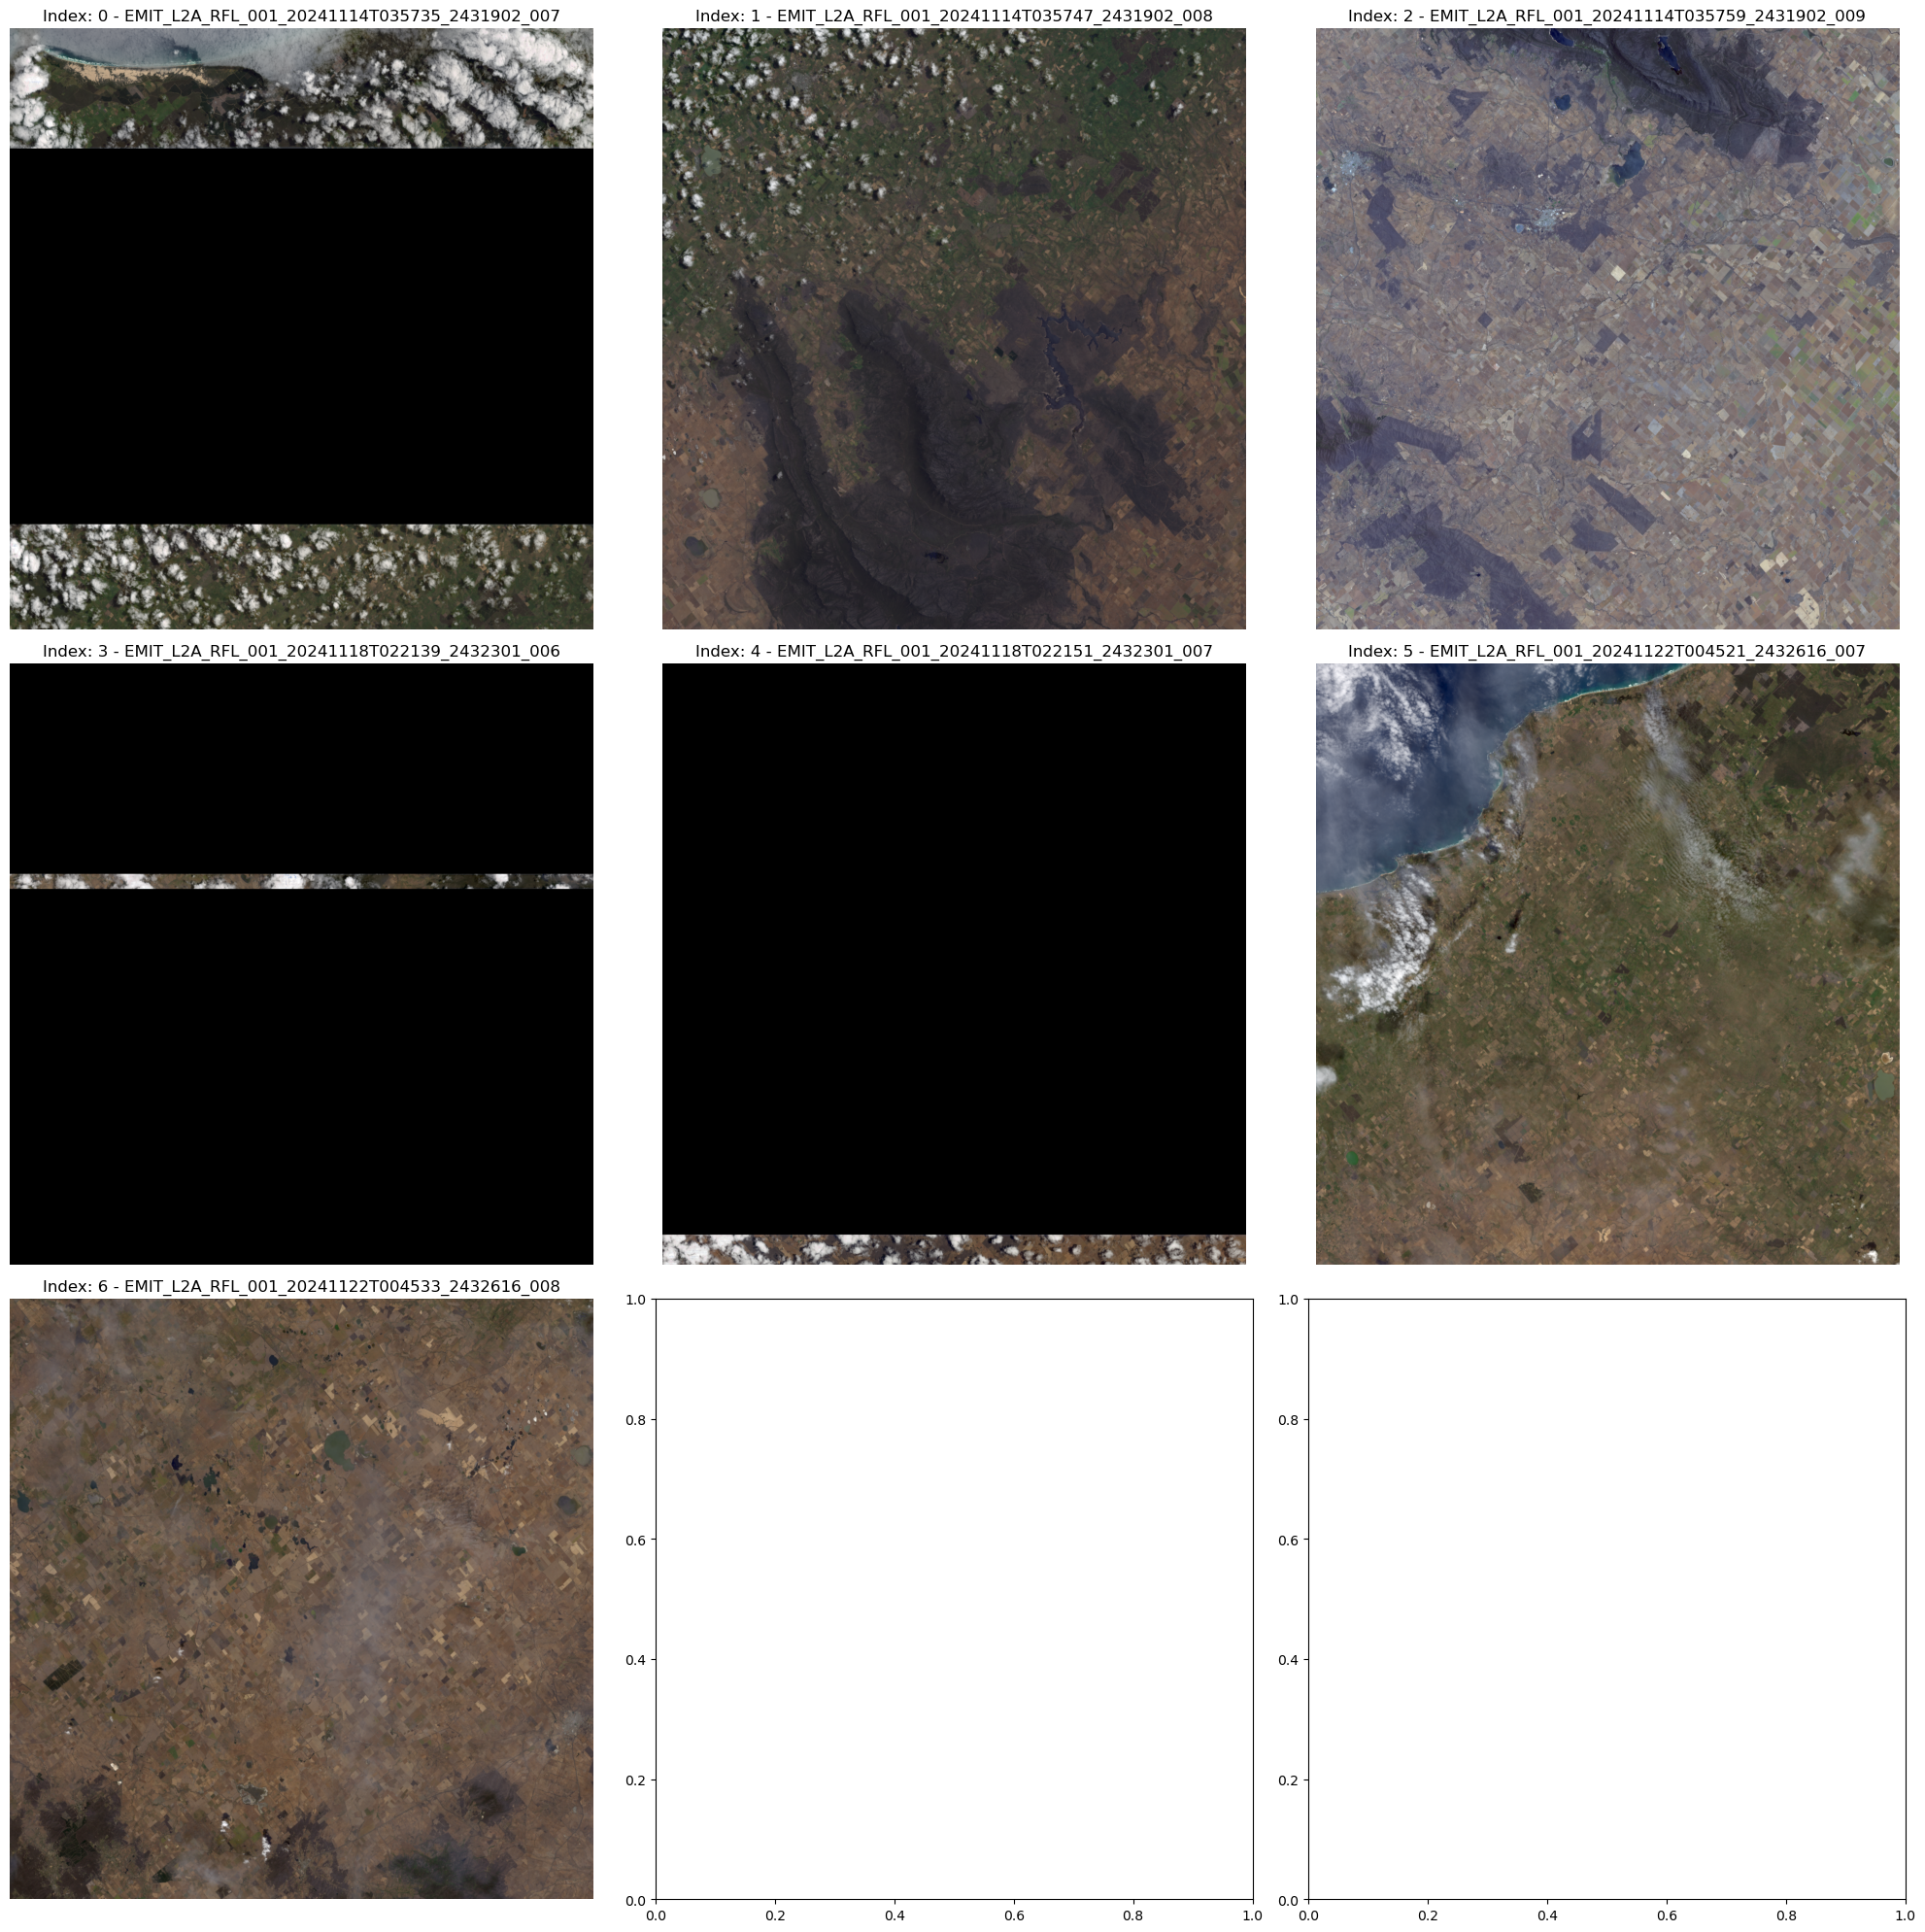

In [12]:
def plot_browse_images(gdf, cols=3):
    """
    Plot browse images using a given GeoDataFrame with the applicable metadata.
    Args:
        gdf - GeoDataFrame including the "browse" metadata from earthaccess
        cols - the number of columns in the desired plot
    
    Returns:
        A plot of browse images
    """
    rows = int(np.ceil(len(gdf)/cols))
    fig, ax = plt.subplots(rows, cols, figsize=(20,20))
    ax = ax.flatten()

    for _n, index in enumerate(gdf.index.to_list()):
        img = io.imread(gdf['browse'][index])
        ax[_n].imshow(img)
        ax[_n].set_title(f"Index: {index} - {gdf['native-id'][index]}")
        ax[_n].axis('off')
    plt.tight_layout()
    plt.show()

plot_browse_images(emit_gdf)

The EMIT granule at index 1 shows Grampians National Park most clearly, with no clouds or bad data! We'll use that granule in our analysis, as long as the PACE granule is similarly good quality. 

At time of writing, PACE browse imagery is still being implemented. Once the implementation is complete, we'll be able to make the same plot with PACE. For this exercise, we'll assume our ROI in each OCI granule is free of clouds and isn't affected by any quality issues, which can be verified by this screenshot from [NASA Worldview](https://worldview.earthdata.nasa.gov/?v=130.20350769629988,-44.84201943466406,151.83477033495035,-32.73702465944704&l=Reference_Labels_15m(hidden),Reference_Features_15m(hidden),Coastlines_15m,OCI_PACE_True_Color,VIIRS_NOAA21_CorrectedReflectance_TrueColor(hidden),VIIRS_NOAA20_CorrectedReflectance_TrueColor(hidden),VIIRS_SNPP_CorrectedReflectance_TrueColor(hidden),MODIS_Aqua_CorrectedReflectance_TrueColor(hidden),MODIS_Terra_CorrectedReflectance_TrueColor(hidden)&lg=true&t=2024-11-14-T18%3A46%3A01Z) for this scene:

![An image of the PACE granule which overlaps with the EMIT granule chosen above. Although there are clouds present in the image, they do not affect the area over or around Grampians National Park, the ROI for this analysis](data/worldview_20241114T035224_browse.png)

In [13]:
# Plot PACE browse images
#plot_browse_images(pace_gdf)

Before we get too excited about using those two granules, the last thing we need to make sure of is that our EMIT granule, and thus our ROI, is in a decent position relative to the entire OCI swath. Its relative location is important because Level 2 (L2) reflectances are in the swath resolution, and OCI's swath is ~2700 km. Because of its wide swath, pixels toward the east and west edges of a L2 OCI granule tend to include greater angular effects. To minimize those effects, it is preferable to choose EMIT and PACE pairs where the ROI is closer to the center of OCI's swath. 

The browse images are great quick looks, but they do not demonstrate well just how broad OCI's swath is, or where the ROI falls within OCI's swath. Instead, we'll make a quick interactive plot with Folium:

In [ ]:
# Create Figure and Select Background Tiles
fig = Figure(width="750px", height="375px")
map1 = folium.Map(tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}', attr='Google')
fig.add_child(map1)

# Plot PACE OCI Results - note we must drop the datetime_obj columns for this to work
pace_gdf.drop(columns=['datetime_obj']).explore(
    "native-id",
    categorical=True,
    tooltip=[
        "native-id",
        "BeginningDateTime",
        "CloudCover",
    ],
    popup=True,
    style_kwds=dict(fillOpacity=0.1, width=2),
    name="PACE OCI",
    m=map1,
    legend=False
)

# Plot EMIT Results - note we must drop the datetime_obj columns for this to work
emit_gdf.drop(columns=['datetime_obj']).explore(
    "native-id",
    categorical=True,
    tooltip=[
        "native-id",
        "BeginningDateTime",
        "CloudCover",
    ],
    popup=True,
    style_kwds=dict(fillOpacity=0.1, width=2),
    name="EMIT",
    m=map1,
    legend=False
)

folium.GeoJson(bbox,
                name='bounding_box',
                ).add_to(map1)

x1, y1, x2, y2 = gdf.union_all().bounds
map1.fit_bounds(bounds=((y1, x1), (y2, x2)))
map1.add_child(folium.LayerControl())
display(fig)

The folium map above illustrates well just how different the area these instruments are observating can be! It also shows clearly where in OCI granule each respective EMIT granule falls - we can see that for the PACE observation on November 14th, 2024, the EMIT granule falls pretty close to its center line. Conversely, most of the other EMIT granules fall to the edges of their paired OCI granules. 

With these quick checks, we can bet confident that the data from November 14th, 2024 is the right data to use. Now we can grab those granules from their respective GeoDataFrames and put them in a single list for easy download later.

In [15]:
# Filter PACE using date of observation, since there is only one per day here
good_pace_gran = pace_gdf[pace_gdf['native-id'].str.contains("20241114")]

# Filter EMIT using index from the browse imagery plot
good_idxs = [1] 
good_emit_grans = emit_gdf[emit_gdf.index.isin(good_idxs)]
keep_granules = good_pace_gran.index.to_list()+good_emit_grans.index.to_list()
keep_granules.sort()

prefire_results = [result for i, result in enumerate(results) if i in keep_granules]
prefire_results

[Collection: {'ShortName': 'EMITL2ARFL', 'Version': '001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': 142.35134887695312, 'Latitude': -36.74950408935547}, {'Longitude': 141.48019409179688, 'Latitude': -37.349632263183594}, {'Longitude': 141.94595336914062, 'Latitude': -38.025718688964844}, {'Longitude': 142.81710815429688, 'Latitude': -37.42559051513672}, {'Longitude': 142.35134887695312, 'Latitude': -36.74950408935547}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-11-14T03:57:47Z', 'EndingDateTime': '2024-11-14T03:57:59Z'}}
 Size(MB): 3579.740264892578
 Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035747_2431902_008/EMIT_L2A_RFL_001_20241114T035747_2431902_008.nc', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035747_2431902_008/EMIT_L2A_RFLUNCERT_001_20241114T035747

### Search and filter for post-fire data

We have our pre-fire results, and so can now repeat the process above to find post fire data. We will combine several of the steps completed above to search and filter the data, especially because the only real change to make is in the time span we include in the `earthaccess.search_data()` call. The fires were controlled around mid-February 2025, so we will set our time span to ~1-2 months after that date.

In [16]:
tspan = ('2025-02-28','2025-03-30')

results = earthaccess.search_data(
    short_name=prods,
    polygon=roi,
    temporal=tspan,
)

gdf = results_to_gdf(results)

print(f'{gdf.shape[0]} granules total')

gdf = gdf[gdf.columns.intersection(keep_cols)]
gdf['datetime_obj'] = pd.to_datetime(gdf['BeginningDateTime'], format='ISO8601')

pace_gdf = gdf[gdf['native-id'].str.contains('OCI')]
emit_gdf = gdf[gdf['native-id'].str.contains('EMIT')]
print(f' PACE OCI Granules: {pace_gdf.shape[0]} \n EMIT Granules: {emit_gdf.shape[0]}')

pace_gdf['intersects'] = pace_gdf.intersects(emit_gdf.union_all())

pace_gdf = pace_gdf[pace_gdf['intersects'] == True]
pace_gdf, emit_gdf = concurrent_match(pace_gdf,emit_gdf, col_name='datetime_obj',time_delta=timedelta(hours=9))
print(f'After concurrent match:\n PACE OCI Granules: {pace_gdf.shape[0]} \n EMIT Granules: {emit_gdf.shape[0]}')

51 granules total
 PACE OCI Granules: 46 
 EMIT Granules: 5
After concurrent match:
 PACE OCI Granules: 2 
 EMIT Granules: 5


We have an even smaller number of colocated granules now, so let's again visualize the EMIT and PACE data.

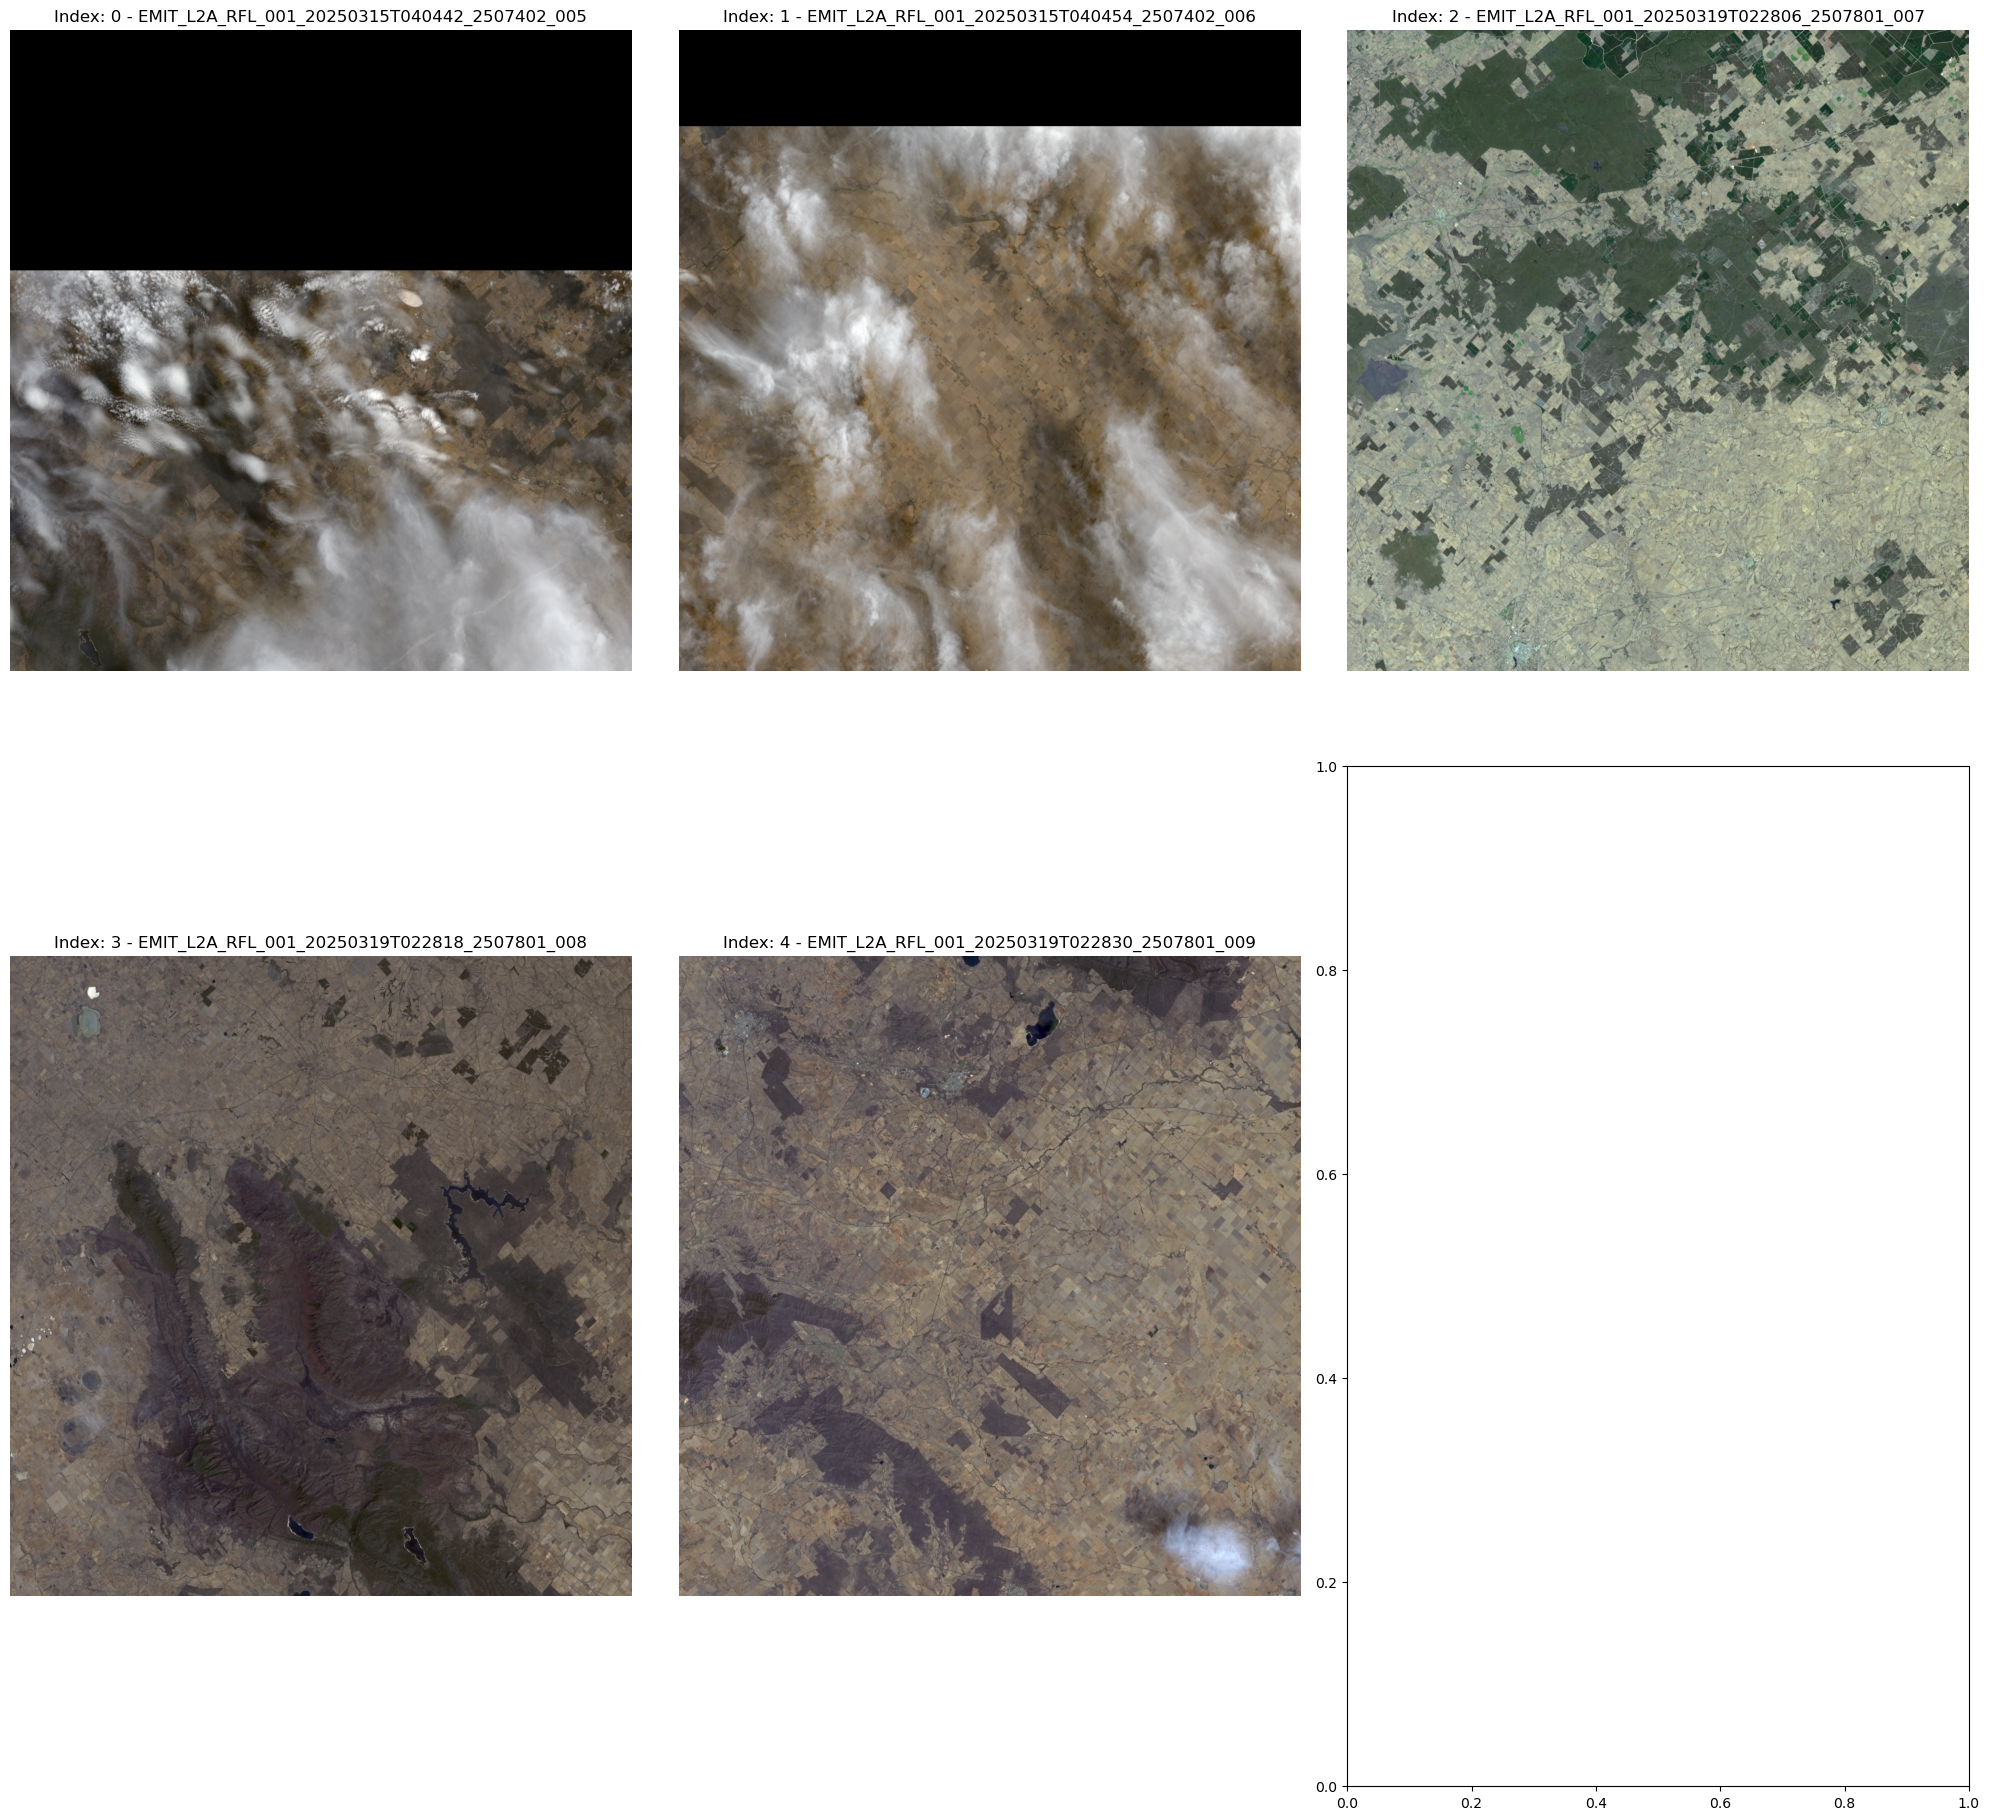

In [17]:
plot_browse_images(emit_gdf)

# PACE browse images not yet available
#plot_browse_images(pace_gdf)

The EMIT data from March 19th, 2025 looks clearest, so let's create another folium map to visualize the PACE and EMIT overlaps.

In [ ]:
fig = Figure(width="750px", height="375px")
map1 = folium.Map(tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}', attr='Google')
fig.add_child(map1)

pace_gdf.drop(columns=['datetime_obj']).explore(
    "native-id",
    categorical=True,
    tooltip=[
        "native-id",
        "BeginningDateTime",
        "CloudCover",
    ],
    popup=True,
    style_kwds=dict(fillOpacity=0.1, width=2),
    name="PACE OCI",
    m=map1,
    legend=False
)

emit_gdf.drop(columns=['datetime_obj']).explore(
    "native-id",
    categorical=True,
    tooltip=[
        "native-id",
        "BeginningDateTime",
        "CloudCover",
    ],
    popup=True,
    style_kwds=dict(fillOpacity=0.1, width=2),
    name="EMIT",
    m=map1,
    legend=False
)

folium.GeoJson(bbox,
                name='bounding_box',
                ).add_to(map1)

x1, y1, x2, y2 = gdf.union_all().bounds
map1.fit_bounds(bounds=((y1, x1), (y2, x2)))
map1.add_child(folium.LayerControl())
display(fig)

This time the EMIT granule is a little farther from the center of the OCI granule than the pre-fire scene, but its position is still perfectly acceptable. We'll extract those two granules from their respective `gdf`s and combine the two lists into a final granule list

In [19]:
good_pace_gran = pace_gdf[pace_gdf['native-id'].str.contains("20250319")]

good_idxs = [3]
good_emit_grans = emit_gdf[emit_gdf.index.isin(good_idxs)]
keep_granules = good_pace_gran.index.to_list()+good_emit_grans.index.to_list()
keep_granules.sort()

postfire_results = [result for i, result in enumerate(results) if i in keep_granules]

# Combine pre- and post-fire results into one list
granules = prefire_results+postfire_results
granules

[Collection: {'ShortName': 'EMITL2ARFL', 'Version': '001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': 142.35134887695312, 'Latitude': -36.74950408935547}, {'Longitude': 141.48019409179688, 'Latitude': -37.349632263183594}, {'Longitude': 141.94595336914062, 'Latitude': -38.025718688964844}, {'Longitude': 142.81710815429688, 'Latitude': -37.42559051513672}, {'Longitude': 142.35134887695312, 'Latitude': -36.74950408935547}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-11-14T03:57:47Z', 'EndingDateTime': '2024-11-14T03:57:59Z'}}
 Size(MB): 3579.740264892578
 Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035747_2431902_008/EMIT_L2A_RFL_001_20241114T035747_2431902_008.nc', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035747_2431902_008/EMIT_L2A_RFLUNCERT_001_20241114T035747

## 4. Downloading data

As a final step, we'll use the list we just created to download (or stream) the data we want. If we inspect the EMIT granules in the print out of `granules` above, we'll see that the `Data` key is a list of three links, not just one as in the PACE datasets. The three links exist because the `EMITL2ARFL` collection includes reflectances, uncertainties, and mask information as separate files. The next two tutorials in this series only require the reflectances and quality masks, so we will filter out the uncertainty files from the final download list. 

In [20]:
urls = []
for i in range(len(granules)):
    links = [l for l in granules[i].data_links(access="external") if "UNCERT" not in l]
    urls.extend(links)

urls

['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035747_2431902_008/EMIT_L2A_RFL_001_20241114T035747_2431902_008.nc',
 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035747_2431902_008/EMIT_L2A_MASK_001_20241114T035747_2431902_008.nc',
 'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20241114T035224.L2.SFREFL.V3_1.nc',
 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250319T022818_2507801_008/EMIT_L2A_RFL_001_20250319T022818_2507801_008.nc',
 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250319T022818_2507801_008/EMIT_L2A_MASK_001_20250319T022818_2507801_008.nc',
 'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250319T042120.L2.SFREFL.V3_1.nc']

Now that we have all the links for the data we want, we can either stream or download the files, depending on user preference.

In [21]:
paths = earthaccess.download(urls, local_path="data")
#paths = earthaccess.open(files)

QUEUEING TASKS | :   0%|          | 0/6 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/6 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/6 [00:00<?, ?it/s]

<div class="alert alert-info" role="alert">

You have completed the first tutorial in this PACE+EMIT series. We suggest proceeding to the second notebook, `02_Align_PACE_EMIT_Grids`, to learn how to align the grids of the instrument datasets you just downloaded. 

</div>
